# Exercise 4: Time Integration Stability and the Lax Method

## Learning Objectives

By completing this exercise, you will:
- Implement the Lax method for time integration
- Apply von Neumann stability analysis
- Understand the CFL condition from a theoretical perspective
- Compare numerical diffusion between different schemes
- Analyze truncation errors in time-stepping methods

---

## Introduction

We continue with Burgers' equation from [Exercise 3 (Section 4A)](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_3.ipynb):

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0   \tag{1}$$

**Setup:**
- Domain: $x \in [-1.4, 2.0]$
- Initial condition:
$$u(x,t=0) = A\left[\tanh\left(\frac{x+x_c}{W}\right)-\tanh\left(\frac{x-x_c}{W}\right)\right]   \tag{2}$$
- Parameters: $A = 1$, $x_c = 0.70$, $W = 0.1$
- Final time: $t_f = 100$

---

## Part 1: The Lax Method

### The Scheme

Add the following **Lax method** to your library:

$$u^{n+1}_j = \frac{1}{2}(u^n_{j+1} + u^n_{j-1}) - \frac{u^n_j \Delta t}{2 \Delta x}(u^n_{j+1} - u^n_{j-1}) \tag{3}$$

### Task 1.1: Stability Analysis

Apply **von Neumann stability analysis** to expression (3). Show that the stability condition $|\xi(k)|^2 \leq 1$ leads to the **Courant-Friedrichs-Lewy (CFL)** condition.

### Task 1.2: Implement the Lax Method

**Implementation:** Fill in the function `evolv_Lax_uadv_burgers` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_4.py).

Run the simulation with the CFL condition imposed.

### Task 1.3: Resolution Study

**Questions:**
1. What do you observe with 64 grid points vs. 128 or higher?
2. What modification is needed in the first (averaging) term on the right-hand side of eq. (3)?
3. How does this modification change the CFL condition?

Finished!
t = 99.99827782895936
steps = 13422


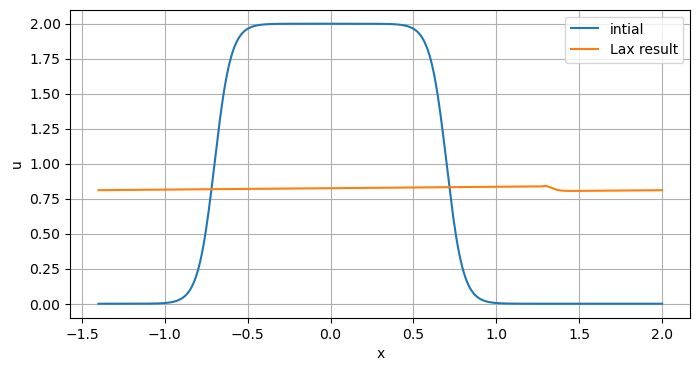

In [9]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import importlib
import nm_lib.nm_ex.nm_lib_ex_4 as nm4
importlib.reload(nm4)
def lax_burgers_one_step_from_lib(x_t, u_t, cfl_cut=0.8):
     # Convert torch tensors to numpy arrays,
    # because nm4 in the lib is written in numpy.
    x_np = x_t.detach().cpu().numpy()
    u_np = u_t.detach().cpu().numpy()
    # Use the lib function to evolve exactly one time step
    # for Burgers' equation with the Lax-type method.
    t_np, unnt_np = nm4.evolv_Lax_uadv_burgers(
        x_np, u_np, nt=1, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    dt = t_np[1] - t_np[0]
     # Convert the updated numpy solution back to torch,
    # so the rest of the notebook can still use torch arrays.
    u_new = torch.tensor(unnt_np[-1], dtype=u_t.dtype, device=u_t.device)
    return u_new, float(dt)


def lax_adv_one_step_from_lib(x_t, u_t, a, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u_np = u_t.detach().cpu().numpy()

    t_np, unnt_np = nm4.evolv_Lax_adv_burgers(
        x_np, u_np, nt=1, a=a, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    dt = t_np[1] - t_np[0]
    u_new = torch.tensor(unnt_np[-1], dtype=u_t.dtype, device=u_t.device)
    return u_new, float(dt)


def ftbs_one_step(u, a, dx, dt):
    N_local = len(u)
    u_new = torch.empty_like(u)
    lam = a * dt / dx

    for j in range(N_local):
        jm = (j - 1) % N_local
        u_new[j] = u[j] - lam * (u[j] - u[jm])

    return u_new

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)

# Problem 4

# In this problem we consider the Burger's equation

# We consider the intial condition

#Define the function

#Intial 
x0=-1.4
xf = 2.0
# Parameters
A = 1.0
xc = 0.70
W = 0.1
tf = 100.0
CFL = 0.8 #Must less 1
N = 400


def burgers_initial(x, A=1.0, xc=0.70, W=0.1):
    return A * (torch.tanh((x + xc)/W) - torch.tanh((x - xc)/W))

#Part 1


# The Lax Method

#Task 1.1
# In this part, we need to work with the von Neumann's Stability analysis.
#The PDF

#Task 1.2
# The code.
"""
def evolv_Lax_uadv_burgers(u, dx, dt):
   
   # One step of the Lax method for Burgers' equation:
   #u_t + u * u_x = 0
   #with periodic boundary conditions.
    
    N_local = len(u)                 # Length of the solution array
    u_new = torch.empty_like(u)      # Create a new array with the same shape
    lam = dt / (2.0 * dx)

    for j in range(N_local):
        # Periodic boundary conditions:
        # if index goes beyond the right end, wrap to the left end
        # if index goes beyond the left end, wrap to the right end
        jp = (j + 1) % N_local       # index j+1
        jm = (j - 1) % N_local       # index j-1

        # Lax update formula (directly from the scheme)
        u_new[j] = (u[jm] + u[j] + u[jp]) / 3.0 - (u[j] * lam) * (u[jp] - u[jm]) #Update the lax step including u[j]

    return u_new
"""

# 4) Build grid x and compute dx

x = torch.linspace(x0, xf, N)
dx = (xf - x0) / (N - 1)

# Intial data
u = burgers_initial(x)
u0 = u.clone()   # Save a copy of the initial condition for plotting


# Time stepping  CFL c

t = 0.0
step = 0

while t < tf:
    u_new, dt = lax_burgers_one_step_from_lib(x, u, cfl_cut=CFL)

    if t + dt > tf:
        break

    u = u_new
    t = t + dt
    step = step + 1

print("Finished!")
print("t =", t)
print("steps =", step)


# 6) Plot 
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), u0.numpy(), label="intial")
plt.plot(x.numpy(), u.numpy(), label="Lax result")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid(True)
plt.show()    

---

## Part 2: Numerical Diffusion

### Task 2.1: Compare Methods

Redo [Exercise 2b](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_2b.ipynb) and compare:
1. The original method from Exercise 2b
2. The Lax method

**Questions:**
1. Which method is more diffusive? Why?

### Task 2.2: Analyze the Truncation Error

Rewrite the Lax method so the right-hand side has the form:

$$\frac{u^{n+1} - u^{n}}{\Delta t} = \ldots$$

**Questions:**
1. What does the remainder (truncation error) term look like?
2. Is the order of convergence the same for both methods?

Finished at t = 0.3962, steps = 38


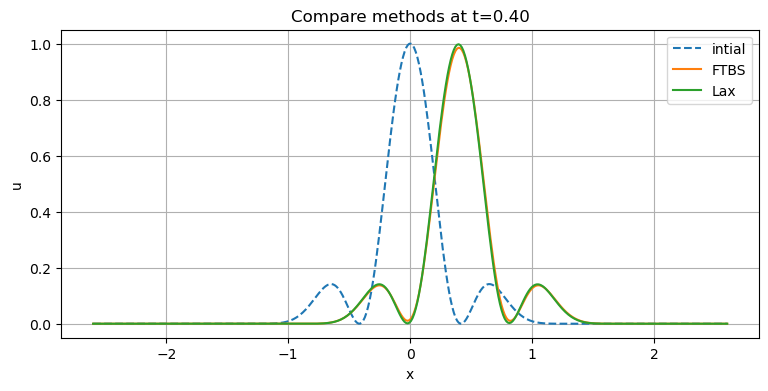

In [10]:
#Part 2 Numerical Diffusion


#Task 2.1: Compare Methods

#  Parameters 

x0 = -2.6
xf = 2.6
a = 1.0          
tf = 0.4        
CFL = 0.8

# Initial condition 
def initial_condition(x):
    return torch.cos(6*torch.pi*x/5)**2 / torch.cosh(5*x**2)

# 
#Original method from Ex 2b (FTFS)

def evolv_FTFS_uadv(u, a, dx, dt):
    N_local = len(u)
    u_new = torch.empty_like(u)
    lam = a * dt / dx

    for j in range(N_local):
        jp = (j + 1) % N_local
        u_new[j] = u[j] - lam * (u[jp] - u[j])

    return u_new


# Lax method for linear advection
"""
def evolv_Lax_uadv(u, a, dx, dt):
    N_local = len(u)
    u_new = torch.empty_like(u)
    lam = a * dt / (2.0 * dx)

    for j in range(N_local):
        jp = (j + 1) % N_local
        jm = (j - 1) % N_local
        u_new[j] = (u[jm] + u[j] + u[jp]) / 3.0 - lam * (u[jp] - u[jm])

    return u_new
"""

# Grid and initial data

x = torch.linspace(x0, xf, N)
dx = (xf - x0) / (N - 1)

u0 = initial_condition(x)

#The FTBS
u_ftbs = u0.clone()
u_lax  = u0.clone()


# Use same dt for both methods 
dt = CFL * dx / abs(a)

# Time stepping

t = 0.0
step = 0
t = 0.0
step = 0
while t < tf:
    dt_use = dt
    if t + dt_use > tf:
        dt_use = tf - t

    u_ftbs = ftbs_one_step(u_ftbs, a, dx, dt_use)

    u_lax_new, dt_lax = lax_adv_one_step_from_lib(x, u_lax, a=a, cfl_cut=CFL)
    if t + dt_lax > tf:
        break

    u_lax = u_lax_new
    t += dt_lax
    step += 1

print(f"Finished at t = {t:.4f}, steps = {step}")


# Plot comparison

plt.figure(figsize=(9, 4))
plt.plot(x.numpy(), u0.numpy(), '--', label='intial')
plt.plot(x.numpy(), u_ftbs.numpy(), label='FTBS')
plt.plot(x.numpy(), u_lax.numpy(), label='Lax')
plt.xlabel('x')
plt.ylabel('u')
plt.title(f'Compare methods at t={t:.2f}')
plt.legend()
plt.grid(True)
plt.show()




#Conclusion. 

#Task 1.2
# The simulation reached the final time t = 100 in 13423 CFL-controlled time steps,
#  and the Lax solution has been strongly smeared buy nmerical diffusion
#Becoming nearly uniform and close to the spatial average of the initial profile

#Task 1.3 
# With N = 64, the solution is clearly under-resolved and significantly more smeared,
# especially near the steep front, due to the strong numerical diffusion of the Lax method.
# As the resolution increases to N = 128 and higher, the solution becomes sharper,
# and the curves begin to overlap, indicating convergence of the numerical solution
# under grid refinement.

# Part 2
# For a > 0, the FTBS scheme is the stable upwind method and is therefore
# a more meaningful method to compare with Lax.
# Both FTBS and Lax remain stable for CFL <= 1.
# In this simulation, the two solutions are very close, but the Lax solution appears
# slightly more diffusive because of its averaging term, so it is slightly more smeared
# than the FTBS solution.

# JMS

<span style="color:green">Good</span>

<span style="color:red"> My bad, can you do FTBS instead, i.e., when it is stable to compare with Lax one.</span>

---

## Background: The Full Burgers' Equation

> **Note:** Equation (1) is a shortened version of the **full Burgers' equation**, which includes a viscosity term:
> $$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$
> The numerical diffusion we observe mimics this physical viscosity term.

---

## Hints

<details>
<summary><b>Hint 1: Von Neumann stability analysis</b></summary>

Substitute $u^n_j = \xi^n e^{ikj\Delta x}$ into the scheme and solve for the amplification factor $\xi$. For stability, require $|\xi| \leq 1$.
</details>

<details>
<summary><b>Hint 2: Identifying numerical diffusion</b></summary>

The averaging term $\frac{1}{2}(u^n_{j+1} + u^n_{j-1})$ introduces numerical diffusion. Expand in Taylor series to see the equivalent diffusion coefficient.
</details>

<details>
<summary><b>Hint 3: Truncation error analysis</b></summary>

Rearranging the Lax method:
$$\frac{u^{n+1}_j - u^n_j}{\Delta t} = \frac{u^n_{j+1} + u^n_{j-1} - 2u^n_j}{2\Delta t} - u^n_j \frac{u^n_{j+1} - u^n_{j-1}}{2\Delta x}$$

The first term on the right looks like a diffusion term with coefficient $\frac{(\Delta x)^2}{2\Delta t}$.
</details>
